In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder.appName("Semana12_Regresion_Lucas").getOrCreate()

# Cargar datos etiquetados generados en Semana 10
df_clusters = spark.read.parquet("/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans")

print(f"Datos cargados: {df_clusters.count()}")
print("Columnas disponibles:")
print(df_clusters.columns)
df_clusters.show(5)

Datos cargados: 4415
Columnas disponibles:
['precio_noche', 'estrellas', 'puntuacion', 'noches', 'features', 'scaledFeatures', 'prediction']
+------------+---------+----------+------+--------------------+--------------------+----------+
|precio_noche|estrellas|puntuacion|noches|            features|      scaledFeatures|prediction|
+------------+---------+----------+------+--------------------+--------------------+----------+
|    386540.0|      4.0|       8.4|   1.0|[386540.0,4.0,8.4...|[2.10697214446551...|         0|
|     64896.0|      0.0|       8.7|   1.0|[64896.0,0.0,8.7,...|[0.35373845989350...|         1|
|     84000.0|      0.0|       9.6|   1.0|[84000.0,0.0,9.6,...|[0.45787152722901...|         1|
|     88224.0|      0.0|       8.3|   1.0|[88224.0,0.0,8.3,...|[0.48089592402681...|         1|
|    171927.0|      0.0|       9.8|   1.0|[171927.0,0.0,9.8...|[0.93714854835598...|         1|
+------------+---------+----------+------+--------------------+--------------------+-------

In [2]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Usar estrellas, puntuación, noches y cluster como predictores
# Variable objetivo: precio_noche
df_num = df_clusters.select(
    col("precio_noche").cast("double").alias("label_precio"),
    col("estrellas").cast("double").alias("estrellas"),
    col("puntuacion").cast("double").alias("puntuacion"),
    col("noches").cast("double").alias("noches"),
    col("prediction").cast("double").alias("cluster")
).na.fill({
    "label_precio": 0.0,
    "estrellas": 0.0,
    "puntuacion": 0.0,
    "noches": 1.0,
    "cluster": 0.0
})

variables_regresion = ["estrellas", "puntuacion", "noches", "cluster"]

# Vectorizar
assembler = VectorAssembler(
    inputCols=variables_regresion,
    outputCol="features_reg",
    handleInvalid="skip"
)
df_vector = assembler.transform(df_num)

# Escalar
scaler = StandardScaler(inputCol="features_reg", outputCol="scaledFeatures_reg", withStd=True, withMean=False)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# Dividir en entrenamiento y prueba
train_reg, test_reg = df_scaled.randomSplit([0.7, 0.3], seed=42)

print(f"Entrenamiento: {train_reg.count()}")
print(f"Prueba: {test_reg.count()}")

Entrenamiento: 3157
Prueba: 1258


In [3]:
# Entrenar modelo
lr_reg = LinearRegression(featuresCol="scaledFeatures_reg", labelCol="label_precio", maxIter=100)
lr_model = lr_reg.fit(train_reg)
predictions = lr_model.transform(test_reg)

# Evaluar
evaluator_r2 = RegressionEvaluator(labelCol="label_precio", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label_precio", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions)
rmse = evaluator_rmse.evaluate(predictions)

print("=" * 50)
print("REGRESIÓN LINEAL - PREDICCIÓN DE PRECIO")
print("=" * 50)
print(f"R²:  {r2 * 100:.2f}%")
print(f"RMSE: ${rmse:,.0f} CLP")
print("=" * 50)

REGRESIÓN LINEAL - PREDICCIÓN DE PRECIO
R²:  2.93%
RMSE: $130,905 CLP


In [4]:
print(f"Intercepto (precio base): ${lr_model.intercept:,.0f} CLP")
print("Coeficientes por variable:")
for i, var in enumerate(variables_regresion):
    print(f"  {var}: ${lr_model.coefficients[i]:,.0f} CLP")

Intercepto (precio base): $370,280 CLP
Coeficientes por variable:
  estrellas: $-36,096 CLP
  puntuacion: $-35,722 CLP
  noches: $-4,826 CLP
  cluster: $-84,668 CLP


+------------+------------------+
|label_precio|        prediction|
+------------+------------------+
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
|         0.0|120048.48582262333|
+------------+------------------+
only showing top 10 rows



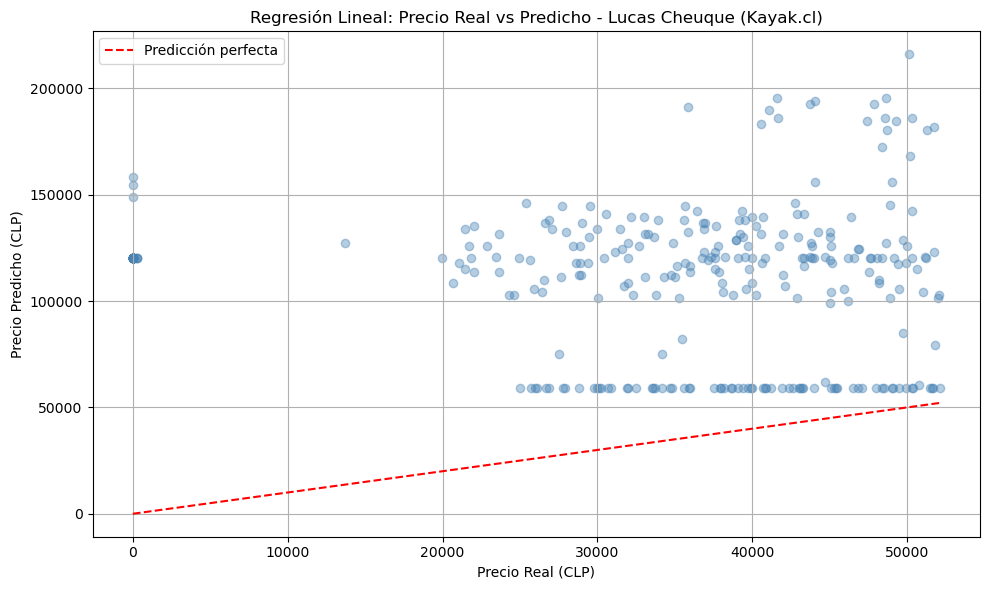

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Mostrar tabla comparativa
predictions.select("label_precio", "prediction").show(10)

# Gráfico real vs predicho
pdf_pred = predictions.select("label_precio", "prediction").limit(300).toPandas()

plt.figure(figsize=(10, 6))
plt.scatter(pdf_pred["label_precio"], pdf_pred["prediction"], alpha=0.4, color="steelblue")
plt.plot(
    [pdf_pred["label_precio"].min(), pdf_pred["label_precio"].max()],
    [pdf_pred["label_precio"].min(), pdf_pred["label_precio"].max()],
    "r--", label="Predicción perfecta"
)
plt.xlabel("Precio Real (CLP)")
plt.ylabel("Precio Predicho (CLP)")
plt.title("Regresión Lineal: Precio Real vs Predicho - Lucas Cheuque (Kayak.cl)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
print("=" * 60)
print("TICKET DE SALIDA - SEMANA 12 (Regresión)")
print("=" * 60)
print(f"""
PREGUNTA 1: ¿El problema es el algoritmo o los datos?

RESPUESTA: El R² obtenido es de {r2 * 100:.2f}%, lo que indica que
el modelo de regresión lineal explica solo el {r2 * 100:.2f}% de la
variabilidad del precio. Esto sugiere que el problema principal son
los DATOS, no el algoritmo. Las variables disponibles (estrellas,
puntuación, noches, cluster) no son suficientes para predecir el
precio con precisión.

PREGUNTA 2: ¿Cómo lo solucionarían sin hacer trampa? ¿Qué datos faltan?

RESPUESTA: Para mejorar la predicción del precio, se necesitarían
datos adicionales como:
- Ubicación exacta (latitud/longitud)
- Temporada de la captura (alta/baja)
- Servicios del alojamiento (piscina, wifi, desayuno, estacionamiento)
- Distancia a puntos turísticos o al centro
- Capacidad del alojamiento (número de habitaciones/camas)
- Precio de la competencia en la misma zona
- Calificaciones más detalladas (limpieza, ubicación, servicio)
- Fecha de captura (para considerar inflación/estacionalidad)
""")
print("=" * 60)

TICKET DE SALIDA - SEMANA 12 (Regresión)

PREGUNTA 1: ¿El problema es el algoritmo o los datos?

RESPUESTA: El R² obtenido es de 2.93%, lo que indica que
el modelo de regresión lineal explica solo el 2.93% de la
variabilidad del precio. Esto sugiere que el problema principal son
los DATOS, no el algoritmo. Las variables disponibles (estrellas,
puntuación, noches, cluster) no son suficientes para predecir el
precio con precisión.

PREGUNTA 2: ¿Cómo lo solucionarían sin hacer trampa? ¿Qué datos faltan?

RESPUESTA: Para mejorar la predicción del precio, se necesitarían
datos adicionales como:
- Ubicación exacta (latitud/longitud)
- Temporada de la captura (alta/baja)
- Servicios del alojamiento (piscina, wifi, desayuno, estacionamiento)
- Distancia a puntos turísticos o al centro
- Capacidad del alojamiento (número de habitaciones/camas)
- Precio de la competencia en la misma zona
- Calificaciones más detalladas (limpieza, ubicación, servicio)
- Fecha de captura (para considerar inflación